# 02. Preprocessing & Feature Engineering

## Superstore Sales Data Mining Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner
from src.features.builder import FeatureBuilder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Data

In [2]:
# Load data
loader = DataLoader()
df = loader.generate_sample_data(n_orders=2000)
print(f"Original shape: {df.shape}")

INFO:src.data.loader:Generated 6986 sample records


Original shape: (6986, 21)


## 2. Data Cleaning

In [3]:
# Initialize cleaner
cleaner = DataCleaner(df)

# Handle missing values
df = cleaner.handle_missing_values(numeric_strategy='median', categorical_strategy='mode')

# Handle duplicates
df, dup_removed = cleaner.handle_duplicates(subset=['Order ID', 'Product ID'])
print(f"Duplicates removed: {dup_removed}")

# Handle outliers
df = cleaner.handle_outliers_iqr(columns=['Sales', 'Profit'], threshold=1.5, method='clip')

# Process dates
df = cleaner.process_dates(['Order Date', 'Ship Date'])

print(f"Cleaned shape: {df.shape}")

INFO:src.data.cleaner:Handling missing values...
INFO:src.data.cleaner:Handling duplicates...
INFO:src.data.cleaner:Removed 2 duplicate rows
INFO:src.data.cleaner:Handling outliers with IQR method (threshold=1.5)...
INFO:src.data.cleaner:Outliers handled: {'Sales': np.int64(0), 'Profit': np.int64(0)}
INFO:src.data.cleaner:Processing date columns...
INFO:src.data.cleaner:Extracted date features from Order Date
INFO:src.data.cleaner:Extracted date features from Ship Date


Duplicates removed: 2
Cleaned shape: (6984, 33)


## 3. Feature Engineering

In [4]:
# Initialize feature builder
builder = FeatureBuilder(df)

# Create RFM features
rfm = builder.create_rfm_features()
print("\nRFM Features:")
print(rfm.head())
print("\nSegment distribution:")
print(rfm['Segment'].value_counts())

INFO:src.features.builder:Creating RFM features...
INFO:src.features.builder:Created RFM features for 849 customers
INFO:src.features.builder:Segment distribution:
Segment
Loyal Customers        283
New Customers          200
Potential Loyalists    110
Lost                    84
At Risk                 59
Champions               57
Promising               56
Name: count, dtype: int64



RFM Features:
     Customer ID  Recency  Frequency  Monetary  Total_Profit  Total_Quantity  \
0  Customer-0001      145          4   5794.94       1182.19              65   
1  Customer-0002     3112          2   2915.21        771.18              35   
2  Customer-0003      461          1   1377.34        -20.40              16   
3  Customer-0007     2699          1   1516.30        307.61              24   
4  Customer-0008      864          4   8166.69       1332.94              76   

   R_Score  F_Score  M_Score  RFM_Score          Segment  
0        1        5        4        154  Loyal Customers  
1        4        2        2        422    New Customers  
2        1        1        1        111             Lost  
3        4        1        1        411    New Customers  
4        2        5        5        255  Loyal Customers  

Segment distribution:
Segment
Loyal Customers        283
New Customers          200
Potential Loyalists    110
Lost                    84
At Risk    

In [5]:
# Create basket data for association rules
basket = builder.create_basket_data(min_items=2)
print(f"\nBasket data shape: {basket.shape}")
print(basket.head())

INFO:src.features.builder:Creating basket data...
INFO:src.features.builder:Created 1953 baskets with min 2 items



Basket data shape: (1953, 3)
    Order ID                                   Items  Item_Count
0  OD-000001                       [Paper, Supplies]           2
1  OD-000002                 [Accessories, Machines]           2
2  OD-000003    [Accessories, Supplies, Furnishings]           3
3  OD-000004  [Binders, Labels, Phones, Furnishings]           4
4  OD-000005                       [Copiers, Phones]           2


In [6]:
# Create customer features
customer_features = builder.create_customer_features()
print(f"\nCustomer features shape: {customer_features.shape}")
print(customer_features.head())

INFO:src.features.builder:Creating customer features...
INFO:src.features.builder:Created 849 customer profiles



Customer features shape: (849, 19)
     Customer ID  Total_Orders First_Order_Date Last_Order_Date  Total_Sales  \
0  Customer-0001             4       2030-06-29      2035-01-12      5794.94   
1  Customer-0002             2       2025-05-16      2026-11-28      2915.21   
2  Customer-0003             1       2034-03-02      2034-03-02      1377.34   
3  Customer-0007             1       2028-01-15      2028-01-15      1516.30   
4  Customer-0008             4       2021-07-06      2033-01-23      8166.69   

   Avg_Order_Value  Sales_Variance  Min_Order_Value  Max_Order_Value  \
0       413.924286      262.832474            32.73           917.67   
1       416.458571      294.312007            69.34           807.47   
2       688.670000      207.040866           542.27           835.07   
3       303.260000      333.307225            21.09           836.95   
4       544.446000      330.807241            25.80           989.20   

   Total_Profit  Avg_Profit  Total_Quantity  Avg_Q

## 4. Visualize RFM

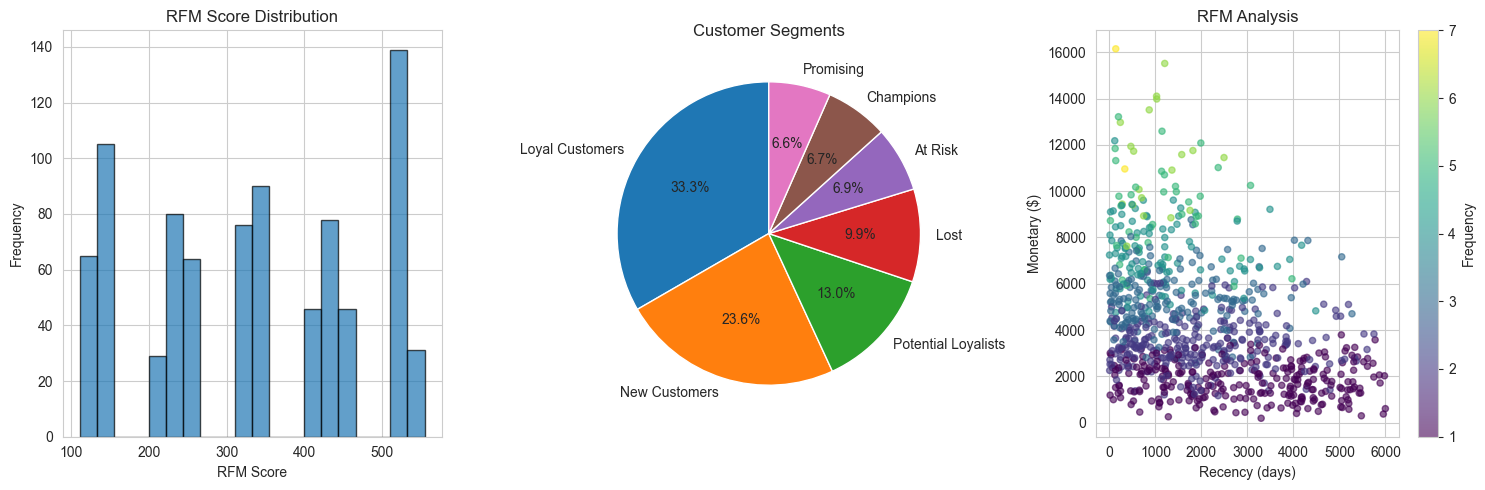

Saved: outputs/figures/06_rfm_analysis.png


In [7]:
# Plot RFM segments
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RFM Score distribution
axes[0].hist(rfm['RFM_Score'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('RFM Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RFM Score Distribution')

# Segment distribution
segment_counts = rfm['Segment'].value_counts()
axes[1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Customer Segments')

# RFM scatter
scatter = axes[2].scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Frequency'], cmap='viridis', alpha=0.6, s=20)
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Monetary ($)')
axes[2].set_title('RFM Analysis')
plt.colorbar(scatter, ax=axes[2], label='Frequency')

plt.tight_layout()
plt.savefig('../outputs/figures/06_rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/06_rfm_analysis.png")

## 5. Save Processed Data

In [8]:
# Save all features
df.to_csv('../data/processed/02_cleaned_data.csv', index=False)
rfm.to_csv('../data/processed/02_rfm_features.csv', index=False)
basket.to_csv('../data/processed/02_basket_data.csv', index=False)
customer_features.to_csv('../data/processed/02_customer_features.csv', index=False)

print("Preprocessing & Feature Engineering completed!")
print("Saved:")
print("  - data/processed/02_cleaned_data.csv")
print("  - data/processed/02_rfm_features.csv")
print("  - data/processed/02_basket_data.csv")
print("  - data/processed/02_customer_features.csv")

Preprocessing & Feature Engineering completed!
Saved:
  - data/processed/02_cleaned_data.csv
  - data/processed/02_rfm_features.csv
  - data/processed/02_basket_data.csv
  - data/processed/02_customer_features.csv
